# Myopericarditis Following COVID-19 Vaccination
## Visualisations of Incidence Rates

This notebook loads the pre-computed summary tables produced by
`data_wrangling_summary.ipynb` and generates one plot per aggregation level.

**Input files** (from `dataimages/`):
- `summary_overall.csv`, `summary_season.csv`, `summary_brand.csv`, `summary_age.csv`
- `summary_season_brand.csv`, `summary_season_age.csv`, `summary_brand_age.csv`
- `summary_season_brand_age.csv`

**Output**: `dataimages/plots/plot_*.png`  (8 PNG files, 150 dpi)

**Author:** Godwin Anguzu

In [1]:
%matplotlib inline
import pandas as pd
from pathlib import Path

DATA_DIR = Path(__file__).parent / 'dataimages' if '__file__' in dir() else Path('dataimages')

# -- Load all summary tables into a dict keyed by aggregation level -----------
AGGREGATIONS = [
    'overall', 'season', 'brand', 'age',
    'season_brand', 'season_age', 'brand_age', 'season_brand_age',
]

all_summaries = {}
missing = []
for key in AGGREGATIONS:
    fpath = DATA_DIR / f'summary_{key}.csv'
    if fpath.exists():
        all_summaries[key] = pd.read_csv(fpath)
    else:
        missing.append(str(fpath))

if missing:
    print('WARNING -- missing files:')
    for m in missing:
        print(f'  {m}')
    print('Run data_wrangling_summary.ipynb first to generate these files.')
else:
    print(f'Loaded {len(all_summaries)} summary tables.')
    for k, df in all_summaries.items():
        print(f'  {k:25s}: {len(df)} rows')


Loaded 8 summary tables.
  overall                  : 1 rows
  season                   : 3 rows
  brand                    : 4 rows
  age                      : 2 rows
  season_brand             : 10 rows
  season_age               : 6 rows
  brand_age                : 7 rows
  season_brand_age         : 19 rows


---
## Plots

One figure per aggregation level. Grey bars = no events in that cell. Error bars = exact Poisson 95% CI.

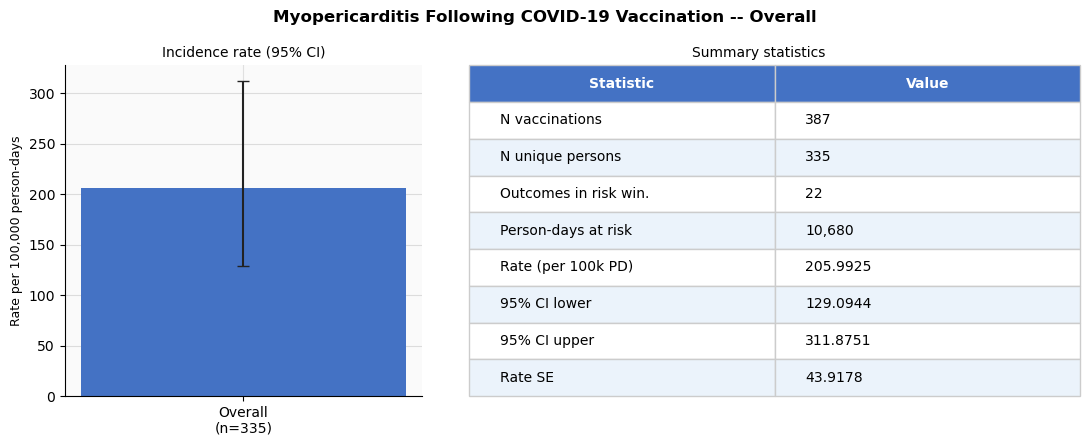

Saved: plot_overall.png


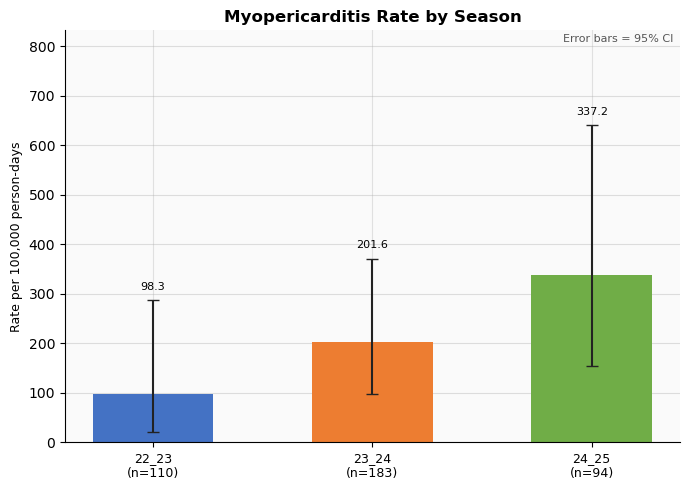

Saved: plot_season.png


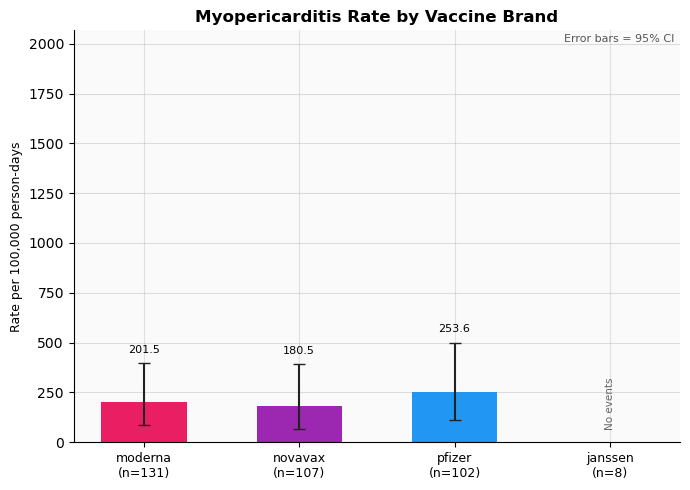

Saved: plot_brand.png


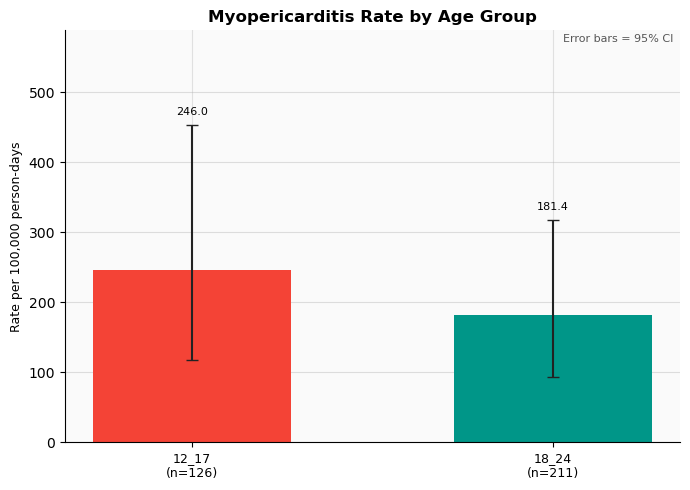

Saved: plot_age.png


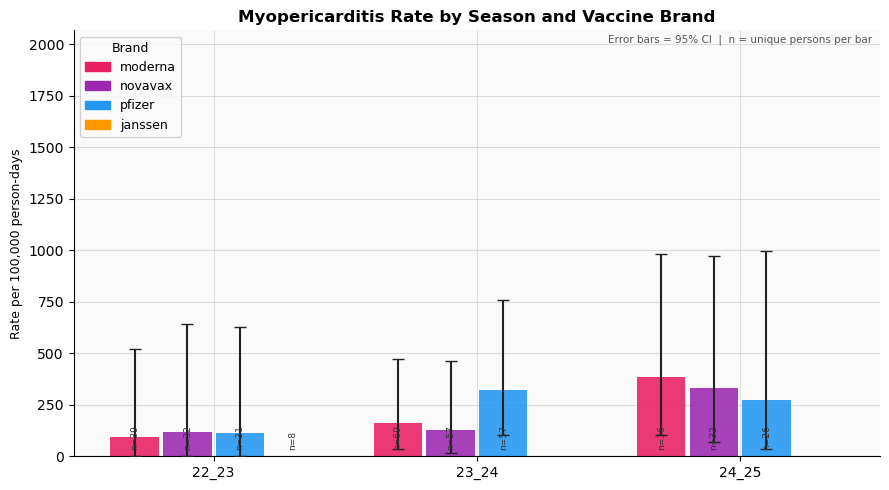

Saved: plot_season_brand.png


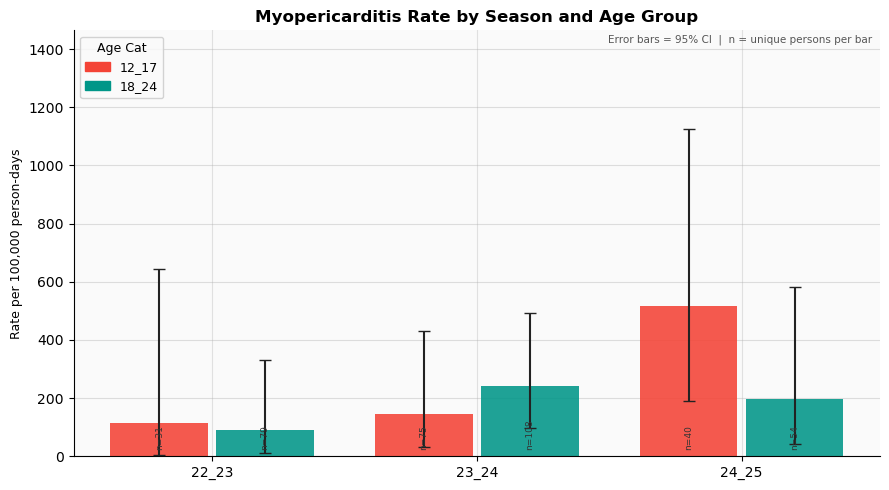

Saved: plot_season_age.png


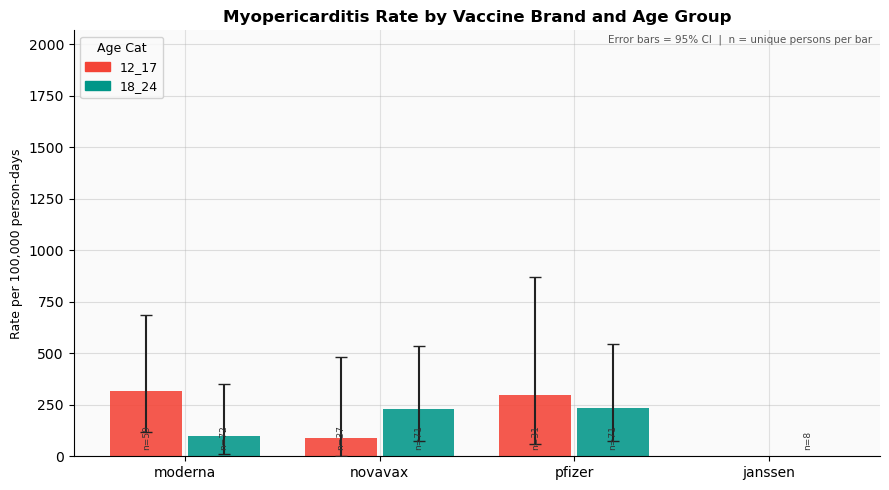

Saved: plot_brand_age.png


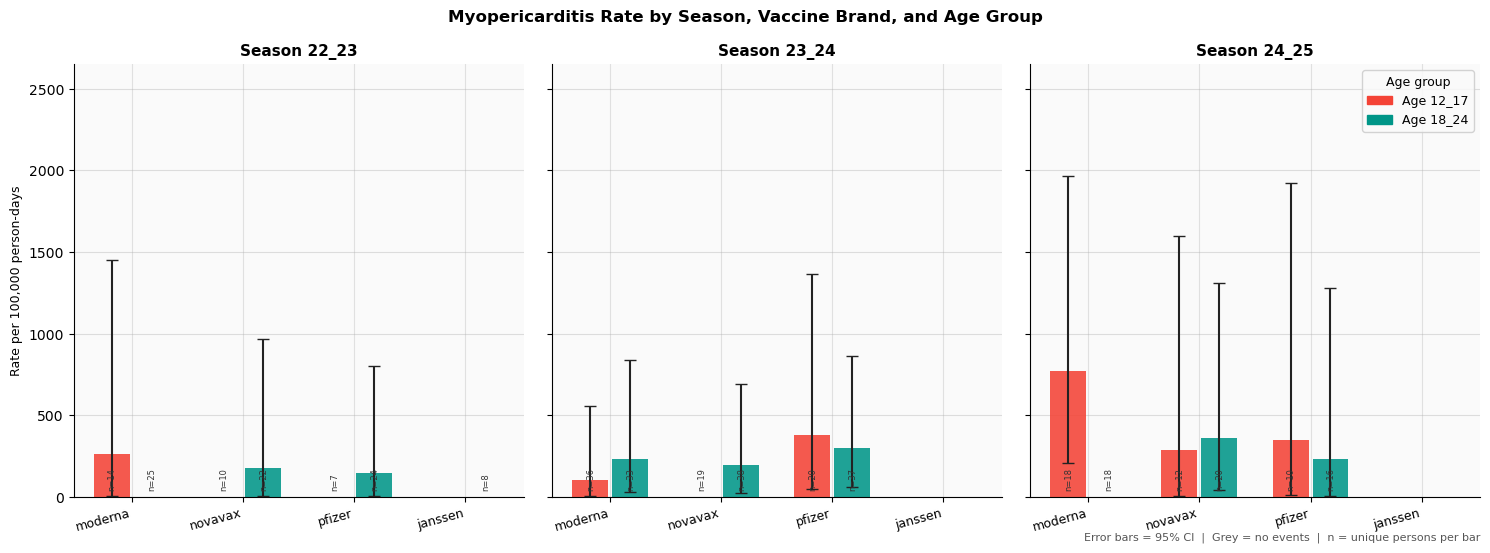

Saved: plot_season_brand_age.png

All 8 plots saved to: dataimages\plots


In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

PLOT_DIR = DATA_DIR / 'plots'
PLOT_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#FAFAFA',
    'axes.grid': True, 'grid.alpha': 0.35,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 10,
})
RATE_LABEL = 'Rate per 100,000 person-days'
ZERO_COLOR = '#CCCCCC'

SEASON_ORDER = ['22_23', '23_24', '24_25']
BRAND_ORDER  = ['moderna', 'novavax', 'pfizer', 'janssen']
AGE_ORDER    = ['12_17', '18_24']

SEASON_COLORS = {'22_23': '#4472C4', '23_24': '#ED7D31', '24_25': '#70AD47'}
BRAND_COLORS  = {'moderna': '#E91E63', 'novavax': '#9C27B0', 'pfizer': '#2196F3', 'janssen': '#FF9800'}
AGE_COLORS    = {'12_17': '#F44336', '18_24': '#009688'}

def _ygrid(ax):
    ax.yaxis.grid(True, alpha=0.4); ax.set_axisbelow(True)

def _ci_bars(ax, xs, rates, los, his):
    for x, r, lo, hi in zip(xs, rates, los, his):
        if r > 0:
            ax.errorbar(x, r, yerr=[[r - lo], [hi - r]], fmt='none',
                        color='#222222', capsize=4, lw=1.5, zorder=5)

def _n_inside(ax, xs, rates, ns, ymax, fontsize=6.5, rotation=90):
    """Print 'n=X' near the base of each bar."""
    for x, r, n in zip(xs, rates, ns):
        if n > 0:
            ax.text(x, ymax * 0.015, f'n={n}', ha='center', va='bottom',
                    fontsize=fontsize, rotation=rotation, color='#333333', zorder=6)

# Overall
ov = all_summaries['overall'].iloc[0]
fig, (ax_b, ax_t) = plt.subplots(1, 2, figsize=(11, 4.5),
                                   gridspec_kw={'width_ratios': [1, 1.8]})
fig.suptitle('Myopericarditis Following COVID-19 Vaccination -- Overall',
             fontsize=12, fontweight='bold')
ax_b.bar([0], [ov['rate_risk']], color='#4472C4', width=0.45, zorder=2)
_ci_bars(ax_b, [0], [ov['rate_risk']], [ov['lower_ci']], [ov['upper_ci']])
ax_b.set_xticks([0])
ax_b.set_xticklabels([f"Overall\n(n={int(ov['num_unique_person']):,})"])
ax_b.set_ylabel(RATE_LABEL, fontsize=9)
ax_b.set_title('Incidence rate (95% CI)', fontsize=10)
_ygrid(ax_b)
rows = [
    ['N vaccinations',        f"{int(ov['num_vax']):,}"],
    ['N unique persons',      f"{int(ov['num_unique_person']):,}"],
    ['Outcomes in risk win.', f"{int(ov['num_outcomes_risk'])}"],
    ['Person-days at risk',   f"{int(ov['pd_risk']):,}"],
    ['Rate (per 100k PD)',    f"{ov['rate_risk']:.4f}"],
    ['95% CI lower',          f"{ov['lower_ci']:.4f}"],
    ['95% CI upper',          f"{ov['upper_ci']:.4f}"],
    ['Rate SE',               f"{ov['rate_se']:.4f}"],
]
ax_t.axis('off')
tbl = ax_t.table(cellText=rows, colLabels=['Statistic', 'Value'],
                  cellLoc='left', loc='center', bbox=[0.05, 0, 0.95, 1])
tbl.auto_set_font_size(False); tbl.set_fontsize(10)
for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor('#CCCCCC')
    if r == 0:
        cell.set_facecolor('#4472C4'); cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#EBF3FB')
ax_t.set_title('Summary statistics', fontsize=10)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'plot_overall.png', dpi=150, bbox_inches='tight'); plt.show(); plt.close()
print('Saved: plot_overall.png')

# 1-D bar chart helper
def simple_bar(summary_key, label_col, color_map, order, title, fname):
    df = all_summaries[summary_key].set_index(label_col).reindex(order).reset_index()
    rates  = df['rate_risk'].fillna(0).values
    los    = df['lower_ci'].fillna(0).values
    his    = df['upper_ci'].fillna(0).values
    ns     = df['num_unique_person'].fillna(0).astype(int).values
    colors = [color_map.get(l, ZERO_COLOR) if rates[i] > 0 else ZERO_COLOR
              for i, l in enumerate(df[label_col])]
    ymax   = max(his.max() * 1.3, 1)
    tick_labels = [f'{l}\n(n={n:,})' for l, n in zip(df[label_col], ns)]
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.bar(range(len(order)), rates, color=colors, width=0.55, zorder=2)
    _ci_bars(ax, range(len(order)), rates, los, his)
    for i, (r, hi) in enumerate(zip(rates, his)):
        if r == 0:
            ax.text(i, ymax * 0.03, 'No events', ha='center', va='bottom',
                    fontsize=7.5, color='#666666', rotation=90)
        else:
            ax.text(i, hi + ymax * 0.02, f'{r:.1f}', ha='center', va='bottom', fontsize=8)
    ax.set_xticks(range(len(order))); ax.set_xticklabels(tick_labels, fontsize=9)
    ax.set_ylabel(RATE_LABEL, fontsize=9); ax.set_ylim(0, ymax)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.text(0.99, 0.99, 'Error bars = 95% CI', transform=ax.transAxes,
            ha='right', va='top', fontsize=8, color='#555555')
    _ygrid(ax)
    plt.tight_layout()
    plt.savefig(PLOT_DIR / fname, dpi=150, bbox_inches='tight'); plt.show(); plt.close()
    print(f'Saved: {fname}')

simple_bar('season', 'season',     SEASON_COLORS, SEASON_ORDER,
           'Myopericarditis Rate by Season',        'plot_season.png')
simple_bar('brand',  'brand_name', BRAND_COLORS,  BRAND_ORDER,
           'Myopericarditis Rate by Vaccine Brand', 'plot_brand.png')
simple_bar('age',    'age_cat',    AGE_COLORS,    AGE_ORDER,
           'Myopericarditis Rate by Age Group',     'plot_age.png')

# Grouped bar chart helper
def grouped_bar(summary_key, x_col, g_col, x_order, g_order, color_map,
                title, fname, figsize=(9, 5)):
    df = all_summaries[summary_key].copy()
    n_x, n_g = len(x_order), len(g_order)
    width   = 0.8 / n_g
    offsets = np.linspace(-(n_g-1)/2*width, (n_g-1)/2*width, n_g)
    fig, ax = plt.subplots(figsize=figsize)
    all_his = []
    all_xs, all_rates, all_ns = [], [], []
    for gi, g in enumerate(g_order):
        sub = df[df[g_col] == g].set_index(x_col)
        xs, rates, los, his, ns = [], [], [], [], []
        for xi, xv in enumerate(x_order):
            xs.append(xi + offsets[gi])
            if xv in sub.index:
                row = sub.loc[xv]
                rates.append(float(row['rate_risk']))
                los.append(float(row['lower_ci']))
                his.append(float(row['upper_ci']))
                ns.append(int(row['num_unique_person']))
            else:
                rates.append(0.0); los.append(0.0); his.append(0.0); ns.append(0)
        bar_cols = [color_map.get(g, ZERO_COLOR) if r > 0 else ZERO_COLOR for r in rates]
        ax.bar(xs, rates, width=width*0.92, color=bar_cols, alpha=0.88, zorder=2)
        _ci_bars(ax, xs, rates, los, his)
        all_his.extend(his)
        all_xs.extend(xs); all_rates.extend(rates); all_ns.extend(ns)
    ymax = max(max(all_his) * 1.3, 1)
    _n_inside(ax, all_xs, all_rates, all_ns, ymax, fontsize=6.5)
    ax.set_xticks(range(n_x)); ax.set_xticklabels(x_order, fontsize=10)
    ax.set_ylabel(RATE_LABEL, fontsize=9); ax.set_ylim(0, ymax)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.text(0.99, 0.99, 'Error bars = 95% CI  |  n = unique persons per bar',
            transform=ax.transAxes, ha='right', va='top', fontsize=7.5, color='#555555')
    leg_title = g_col.replace('_name', '').replace('_', ' ').title()
    handles = [mpatches.Patch(color=color_map.get(g, ZERO_COLOR), label=g) for g in g_order]
    ax.legend(handles=handles, title=leg_title, fontsize=9, title_fontsize=9,
              loc='upper left', framealpha=0.85)
    _ygrid(ax)
    plt.tight_layout()
    plt.savefig(PLOT_DIR / fname, dpi=150, bbox_inches='tight'); plt.show(); plt.close()
    print(f'Saved: {fname}')

grouped_bar('season_brand', 'season',     'brand_name', SEASON_ORDER, BRAND_ORDER, BRAND_COLORS,
            'Myopericarditis Rate by Season and Vaccine Brand',    'plot_season_brand.png')
grouped_bar('season_age',   'season',     'age_cat',    SEASON_ORDER, AGE_ORDER,   AGE_COLORS,
            'Myopericarditis Rate by Season and Age Group',        'plot_season_age.png')
grouped_bar('brand_age',    'brand_name', 'age_cat',    BRAND_ORDER,  AGE_ORDER,   AGE_COLORS,
            'Myopericarditis Rate by Vaccine Brand and Age Group', 'plot_brand_age.png')

# Season x Brand x Age facet
df3 = all_summaries['season_brand_age'].copy()
fig, axes = plt.subplots(1, 3, figsize=(15, 5.5), sharey=True)
fig.suptitle('Myopericarditis Rate by Season, Vaccine Brand, and Age Group',
             fontsize=12, fontweight='bold')
width   = 0.36
offsets = [-width/2, width/2]
all_his3 = df3['upper_ci'].dropna().tolist()
ymax3    = max(all_his3) * 1.35 if all_his3 else 1
for si, season in enumerate(SEASON_ORDER):
    ax = axes[si]
    sub_s = df3[df3['season'] == season]
    for ai, age in enumerate(AGE_ORDER):
        sub_a = sub_s[sub_s['age_cat'] == age].set_index('brand_name')
        xs, rates, los, his, ns = [], [], [], [], []
        for bi, brand in enumerate(BRAND_ORDER):
            xs.append(bi + offsets[ai])
            if brand in sub_a.index:
                rates.append(float(sub_a.loc[brand, 'rate_risk']))
                los.append(float(sub_a.loc[brand, 'lower_ci']))
                his.append(float(sub_a.loc[brand, 'upper_ci']))
                ns.append(int(sub_a.loc[brand, 'num_unique_person']))
            else:
                rates.append(0.0); los.append(0.0); his.append(0.0); ns.append(0)
        bar_cols = [AGE_COLORS[age] if r > 0 else ZERO_COLOR for r in rates]
        ax.bar(xs, rates, width=width*0.9, color=bar_cols, alpha=0.88, zorder=2)
        _ci_bars(ax, xs, rates, los, his)
        _n_inside(ax, xs, rates, ns, ymax3, fontsize=6, rotation=90)
    ax.set_xticks(range(len(BRAND_ORDER)))
    ax.set_xticklabels(BRAND_ORDER, rotation=15, ha='right', fontsize=9)
    ax.set_ylim(0, ymax3)
    ax.set_title(f'Season {season}', fontsize=11, fontweight='bold')
    if si == 0:
        ax.set_ylabel(RATE_LABEL, fontsize=9)
    if si == 2:
        handles = [mpatches.Patch(color=AGE_COLORS[a], label=f'Age {a}') for a in AGE_ORDER]
        ax.legend(handles=handles, title='Age group', fontsize=9, title_fontsize=9,
                  loc='upper right', framealpha=0.85)
    _ygrid(ax)
fig.text(0.99, 0.01,
         'Error bars = 95% CI  |  Grey = no events  |  n = unique persons per bar',
         ha='right', va='bottom', fontsize=8, color='#555555')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'plot_season_brand_age.png', dpi=150, bbox_inches='tight'); plt.show(); plt.close()
print('Saved: plot_season_brand_age.png')

print(f'\nAll 8 plots saved to: {PLOT_DIR}')
